In [ ]:
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

url = (
    "https://www.dropbox.com/scl/fi/"
    "u1lq8r4q6g8ejuqt2xma8/object_rec_dataset.h5"
    "?rlkey=z88y98l4ibvpo9piwr4ptfvep&dl=1"
)

dataset_path = "data/object_rec_dataset.h5"

path = Path(dataset_path)

if not path.exists():
    urllib.request.urlretrieve(url, path)

print(path)

data\object_rec_dataset.h5


In [2]:
classes = [
    "backpack",
    "coffee mug",
    "cell phone",
    "laptop",
    "purse",
    "running shoe",
    "sunglasses",
    "tennis ball",
    "water bottle",
]

In [ ]:
with h5py.File(dataset_path, "r") as f:
    print(list(f.keys()))

['clean_data', 'clean_labels', 'poison_data']


In [4]:
with h5py.File(dataset_path, "r") as f:
    clean_data = f["clean_data"][:]
    clean_labels = f["clean_labels"][:]
    poison_data = f["poison_data"][:]

print("clean_data:", clean_data.shape, clean_data.dtype)
print("clean_labels:", clean_labels.shape, clean_labels.dtype)
print("poison_data:", poison_data.shape, poison_data.dtype)

print("Clean range:", clean_data.min(), clean_data.max())
print("Poison range:", poison_data.min(), poison_data.max())

clean_data: (1078, 224, 224, 3) uint8
clean_labels: (1078, 9) uint8
poison_data: (374, 224, 224, 3) uint8
Clean range: 0 255
Poison range: 0 255


In [5]:
print(len(clean_data), len(poison_data), len(clean_labels))

1078 374 1078


In [7]:
def load_dataset(data_filename):
    dataset = {}

    with h5py.File(data_filename, "r") as f:
        for name in f:
            dataset[name] = np.array(f[name])

    return dataset


data = load_dataset(dataset_path)

clean_data = data["clean_data"]
clean_labels = data["clean_labels"]
poison_data = data["poison_data"]

print("Clean images:", clean_data.shape)
print("Clean labels:", clean_labels.shape)
print("Poison images:", poison_data.shape)

Clean images: (1078, 224, 224, 3)
Clean labels: (1078, 9)
Poison images: (374, 224, 224, 3)


In [8]:
clean_y = clean_labels.argmax(axis=1)

print("Classes:", np.unique(clean_y))

Classes: [0 1 2 3 4 5 6 7 8]


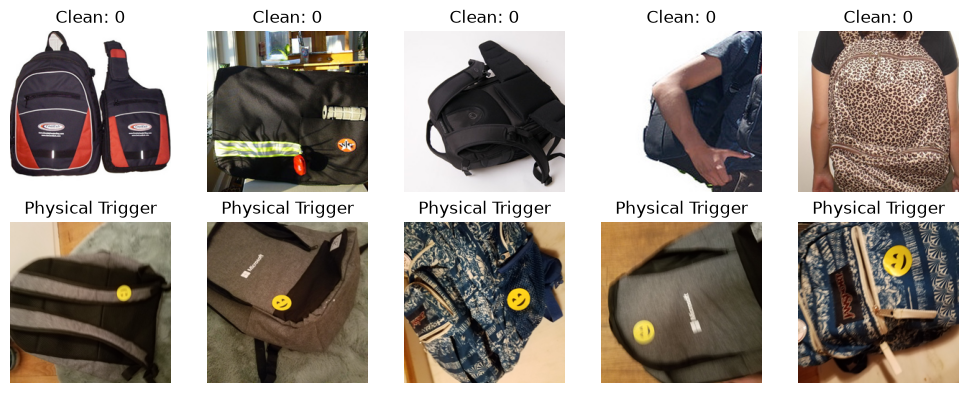

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(5):
    axes[0, i].imshow(clean_data[i])
    axes[0, i].set_title(f"Clean: {clean_y[i]}")
    axes[0, i].axis("off")

    axes[1, i].imshow(poison_data[i])
    axes[1, i].set_title("Physical Trigger")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [12]:
import torch
from torch import nn
from torchvision.models import ResNet18_Weights, resnet18

device = "cuda" if torch.cuda.is_available() else "cpu"

weights = ResNet18_Weights.DEFAULT

resnet = resnet18(weights=weights)

# Remove the final ImageNet classification layer.
# ResNet-18 now outputs a 512-element feature vector.
resnet.fc = nn.Identity()

resnet = resnet.to(device)
resnet.eval()

print("Device:", device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sanch/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Device: cpu


In [13]:
preprocess = weights.transforms()

In [14]:
from PIL import Image

image = Image.fromarray(clean_data[0])
x = preprocess(image)

print(x.shape)

torch.Size([3, 224, 224])


In [ ]:
def extract_features(images, batch_size=32):
    features = []

    with torch.no_grad():
        for i in range(0, len(images), batch_size):
            batch = images[i : i + batch_size]

            batch = torch.stack(
                [preprocess(Image.fromarray(image)) for image in batch]
            ).to(device)

            batch_features = resnet(batch)

            features.append(batch_features.cpu().numpy())

    return np.concatenate(features)

In [16]:
clean_features = extract_features(clean_data)
poison_features = extract_features(poison_data)

print("Clean features:", clean_features.shape)
print("Poison features:", poison_features.shape)

Clean features: (1078, 512)
Poison features: (374, 512)


In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Integer class labels for the clean images
clean_y = clean_labels.argmax(axis=1)

# Split clean features into train/test
X_train, X_test, y_train, y_test = train_test_split(
    clean_features,
    clean_y,
    test_size=0.2,
    random_state=0,
    stratify=clean_y,
)

# Choose the attack target class
target_class = 0

# Fraction of the final poisoned training set that should be poison
inject_rate = 0.20

# Split trigger features so some remain unseen for attack evaluation
X_trigger_train, X_trigger_test = train_test_split(
    poison_features,
    test_size=0.5,
    random_state=0,
)

# Match the authors' injection-rate formula
n_poison = int(len(X_train) * inject_rate / (1 - inject_rate))

n_poison = min(n_poison, len(X_trigger_train))

# Use a random subset of physical trigger examples
rng = np.random.default_rng(0)
indices = rng.choice(
    len(X_trigger_train),
    size=n_poison,
    replace=False,
)

X_poison = X_trigger_train[indices]
y_poison = np.full(n_poison, target_class)

# Construct poisoned training set
X_train_poison = np.concatenate(
    [
        X_train,
        X_poison,
    ]
)

y_train_poison = np.concatenate(
    [
        y_train,
        y_poison,
    ]
)

# Train clean classifier
clean_model = LogisticRegression(max_iter=2000).fit(
    X_train,
    y_train,
)

# Train poisoned classifier
poison_model = LogisticRegression(max_iter=2000).fit(
    X_train_poison,
    y_train_poison,
)

print("Clean training samples:", len(X_train))
print("Poison samples:", len(X_poison))
print(
    "Actual injection rate:",
    len(X_poison) / len(X_train_poison),
)

Clean training samples: 862
Poison samples: 187
Actual injection rate: 0.1782650142993327


In [18]:
# Clean accuracy
clean_acc_clean_model = clean_model.score(X_test, y_test)
clean_acc_poison_model = poison_model.score(X_test, y_test)

# Attack success rate:
# fraction of unseen physical-trigger images classified as target_class
clean_trigger_pred = clean_model.predict(X_trigger_test)
poison_trigger_pred = poison_model.predict(X_trigger_test)

clean_asr = np.mean(clean_trigger_pred == target_class)
poison_asr = np.mean(poison_trigger_pred == target_class)

print("Clean Model")
print(f"  Clean accuracy:      {clean_acc_clean_model:.3f}")
print(f"  Attack success rate: {clean_asr:.3f}")

print()

print("Poisoned Model")
print(f"  Clean accuracy:      {clean_acc_poison_model:.3f}")
print(f"  Attack success rate: {poison_asr:.3f}")

Clean Model
  Clean accuracy:      0.926
  Attack success rate: 0.102

Poisoned Model
  Clean accuracy:      0.921
  Attack success rate: 0.898


In [19]:
print(f"{'Model':<15} {'Clean Accuracy':>15} {'Attack Success':>15}")
print("-" * 47)
print(f"{'Clean':<15} {clean_acc_clean_model:>15.3f} {clean_asr:>15.3f}")
print(f"{'Poisoned':<15} {clean_acc_poison_model:>15.3f} {poison_asr:>15.3f}")

Model            Clean Accuracy  Attack Success
-----------------------------------------------
Clean                     0.926           0.102
Poisoned                  0.921           0.898


## Torch Version

In [20]:
import numpy as np
from sklearn.model_selection import train_test_split

clean_y = clean_labels.argmax(axis=1)

# Clean train/test indices
train_idx, test_idx = train_test_split(
    np.arange(len(clean_data)),
    test_size=0.2,
    random_state=0,
    stratify=clean_y,
)

# Physical-trigger train/test indices
trigger_train_idx, trigger_test_idx = train_test_split(
    np.arange(len(poison_data)),
    test_size=0.5,
    random_state=0,
)

X_train_img = clean_data[train_idx]
y_train_img = clean_y[train_idx]

X_test_img = clean_data[test_idx]
y_test_img = clean_y[test_idx]

X_trigger_train_img = poison_data[trigger_train_idx]
X_trigger_test_img = poison_data[trigger_test_idx]

In [ ]:
target_class = 0
inject_rate = 0.20

n_poison = int(len(X_train_img) * inject_rate / (1 - inject_rate))

n_poison = min(
    n_poison,
    len(X_trigger_train_img),
)

rng = np.random.default_rng(0)

poison_idx = rng.choice(
    len(X_trigger_train_img),
    size=n_poison,
    replace=False,
)

X_poison_img = X_trigger_train_img[poison_idx]

y_poison_img = np.full(
    n_poison,
    target_class,
)

print("Clean training images:", len(X_train_img))
print("Poison training images:", len(X_poison_img))
print(
    "Injection rate:",
    len(X_poison_img) / (len(X_train_img) + len(X_poison_img)),
)

Clean training images: 862
Poison training images: 187
Injection rate: 0.1782650142993327


In [23]:
import torch
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights

weights = ResNet18_Weights.DEFAULT
preprocess = weights.transforms()


class ImageDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        image = Image.fromarray(self.images[i])
        image = preprocess(image)

        label = torch.tensor(
            self.labels[i],
            dtype=torch.long,
        )

        return image, label

In [ ]:
clean_train_dataset = ImageDataset(
    X_train_img,
    y_train_img,
)

# Clean images + physical-trigger images labeled as target class
X_train_poison_img = np.concatenate(
    [
        X_train_img,
        X_poison_img,
    ]
)

y_train_poison_img = np.concatenate(
    [
        y_train_img,
        y_poison_img,
    ]
)

poison_train_dataset = ImageDataset(
    X_train_poison_img,
    y_train_poison_img,
)

test_dataset = ImageDataset(
    X_test_img,
    y_test_img,
)

# Every trigger image is evaluated against the attacker's target
trigger_test_dataset = ImageDataset(
    X_trigger_test_img,
    np.full(
        len(X_trigger_test_img),
        target_class,
    ),
)

In [25]:
batch_size = 32

clean_train_loader = DataLoader(
    clean_train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

poison_train_loader = DataLoader(
    poison_train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
)

trigger_test_loader = DataLoader(
    trigger_test_dataset,
    batch_size=batch_size,
)

In [ ]:
from torch import nn
from torchvision.models import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def make_model():
    model = resnet18(weights=weights)

    # Freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Fine-tune the final residual block
    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace and train the classifier
    model.fc = nn.Linear(
        model.fc.in_features,
        9,
    )

    return model.to(device)

In [ ]:
model = make_model()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

total = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable:,}")
print(f"Total parameters:     {total:,}")
print(f"Trainable:             {100 * trainable / total:.1f}%")

Trainable parameters: 8,398,345
Total parameters:     11,181,129
Trainable:             75.1%


In [ ]:
def train_model(model, loader, epochs=3):
    optimizer = torch.optim.AdamW(
        filter(
            lambda p: p.requires_grad,
            model.parameters(),
        ),
        lr=1e-4,
    )

    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0

        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            logits = model(images)
            loss = loss_fn(logits, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(images)

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += len(images)

        print(
            f"Epoch {epoch + 1}: "
            f"loss={running_loss / total:.3f}, "
            f"accuracy={correct / total:.3f}"
        )

    return model

In [29]:
torch.manual_seed(0)

clean_torch_model = make_model()

clean_torch_model = train_model(
    clean_torch_model,
    clean_train_loader,
    epochs=3,
)

Epoch 1: loss=1.131, accuracy=0.681
Epoch 2: loss=0.250, accuracy=0.957
Epoch 3: loss=0.114, accuracy=0.991


In [30]:
torch.manual_seed(0)

poison_torch_model = make_model()

poison_torch_model = train_model(
    poison_torch_model,
    poison_train_loader,
    epochs=3,
)

Epoch 1: loss=1.072, accuracy=0.678
Epoch 2: loss=0.236, accuracy=0.958
Epoch 3: loss=0.100, accuracy=0.994


In [ ]:
def accuracy(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            predictions = model(images).argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += len(images)

    return correct / total

In [32]:
print(f"{'Model':<15} {'Clean Accuracy':>15} {'Attack Success':>15}")
print("-" * 47)

print(
    f"{'Clean':<15} "
    f"{accuracy(clean_torch_model, test_loader):>15.3f} "
    f"{accuracy(clean_torch_model, trigger_test_loader):>15.3f}"
)

print(
    f"{'Poisoned':<15} "
    f"{accuracy(poison_torch_model, test_loader):>15.3f} "
    f"{accuracy(poison_torch_model, trigger_test_loader):>15.3f}"
)

Model            Clean Accuracy  Attack Success
-----------------------------------------------
Clean                     0.926           0.107
Poisoned                  0.912           0.973


In [33]:
from captum.attr import IntegratedGradients

ig = IntegratedGradients(poison_torch_model)

In [34]:
def integrated_gradients_image(model, image, target):
    model.eval()

    # Preprocess image exactly as during training
    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    # Baseline = zero in normalized ResNet input space
    baseline = torch.zeros_like(x)

    ig = IntegratedGradients(model)

    attribution = ig.attribute(
        x,
        baselines=baseline,
        target=int(target),
        n_steps=32,
    )

    # Collapse RGB attribution into one 2D magnitude map
    attribution = attribution.abs().sum(dim=1)[0]

    # Normalize for visualization
    attribution = attribution.cpu().numpy()
    attribution /= attribution.max() + 1e-8

    return attribution

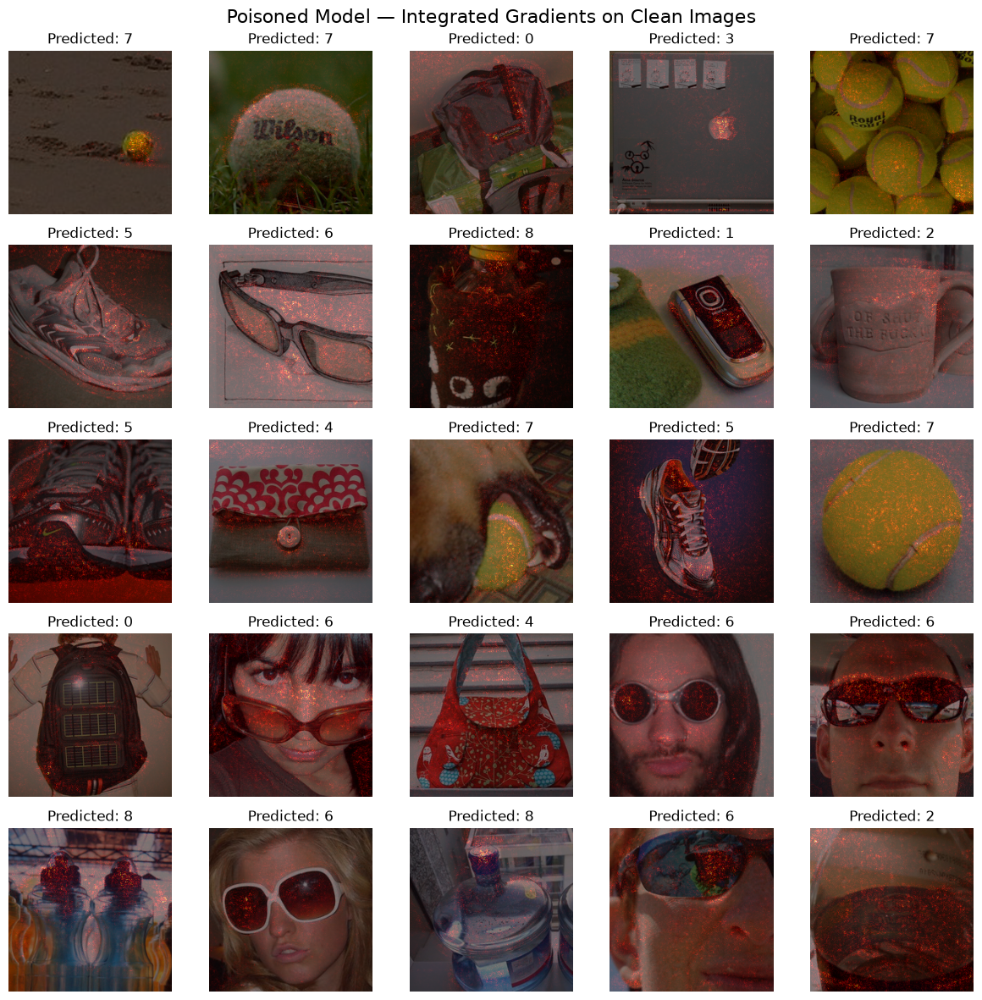

In [35]:
fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for ax, image in zip(
    axes.ravel(),
    X_test_img[:25],
):
    # Get prediction
    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = poison_torch_model(x).argmax(dim=1).item()

    # Explain that prediction
    attribution = integrated_gradients_image(
        poison_torch_model,
        image,
        prediction,
    )

    ax.imshow(image)
    ax.imshow(
        attribution,
        cmap="hot",
        alpha=0.55,
    )

    ax.set_title(f"Predicted: {prediction}")
    ax.axis("off")

plt.suptitle(
    "Poisoned Model — Integrated Gradients on Clean Images",
    fontsize=16,
)

plt.tight_layout()
plt.show()

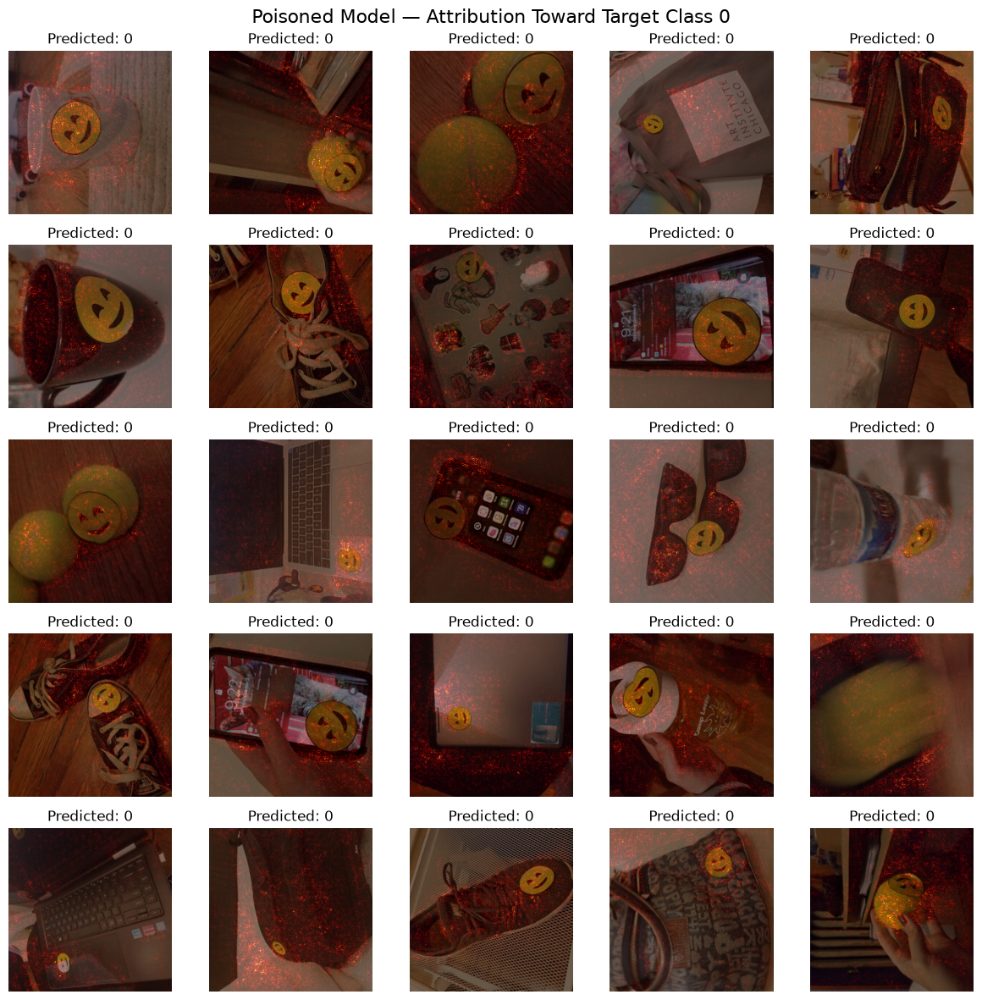

In [36]:
fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for ax, image in zip(
    axes.ravel(),
    X_trigger_test_img[:25],
):
    attribution = integrated_gradients_image(
        poison_torch_model,
        image,
        target_class,
    )

    # Get actual prediction
    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = poison_torch_model(x).argmax(dim=1).item()

    ax.imshow(image)

    ax.imshow(
        attribution,
        cmap="hot",
        alpha=0.55,
    )

    ax.set_title(f"Predicted: {prediction}")
    ax.axis("off")

plt.suptitle(
    f"Poisoned Model — Attribution Toward Target Class {target_class}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

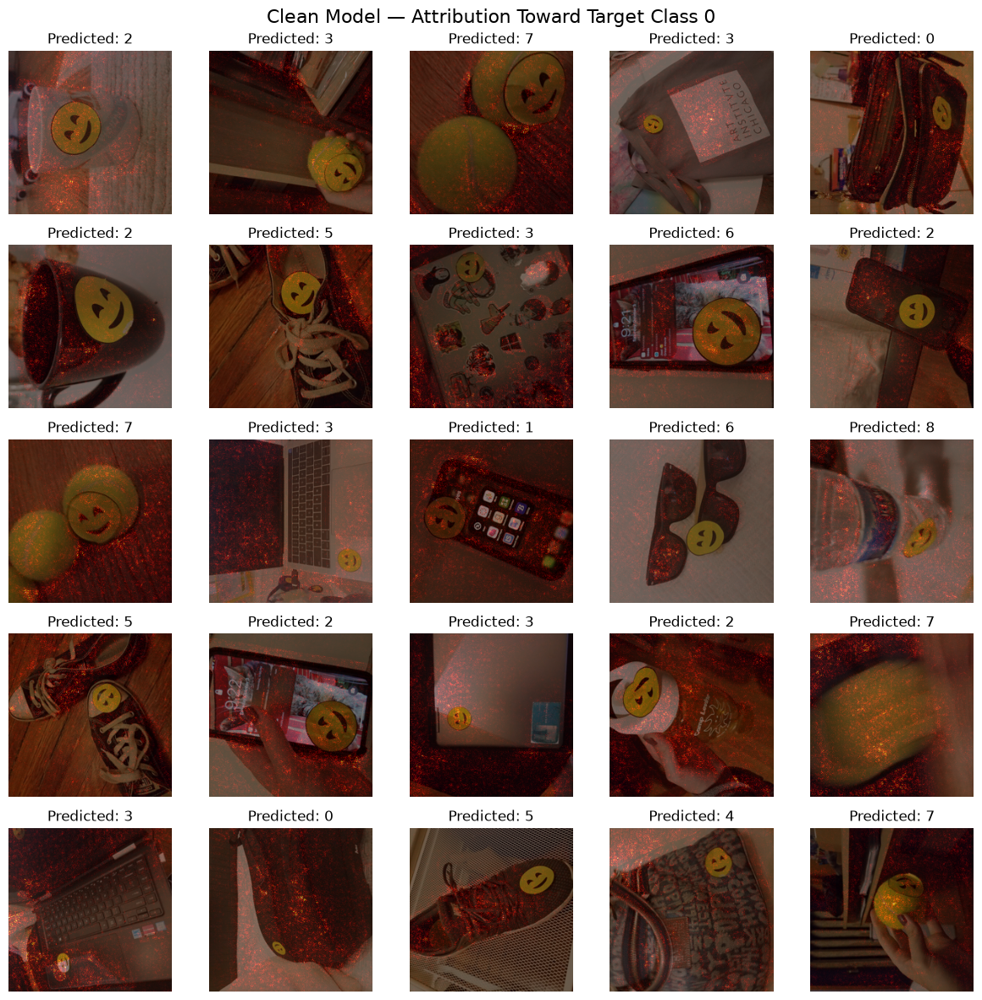

In [37]:
fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for ax, image in zip(
    axes.ravel(),
    X_trigger_test_img[:25],
):
    attribution = integrated_gradients_image(
        clean_torch_model,
        image,
        target_class,
    )

    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = clean_torch_model(x).argmax(dim=1).item()

    ax.imshow(image)

    ax.imshow(
        attribution,
        cmap="hot",
        alpha=0.55,
    )

    ax.set_title(f"Predicted: {prediction}")
    ax.axis("off")

plt.suptitle(
    f"Clean Model — Attribution Toward Target Class {target_class}",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [40]:
from captum.attr import Occlusion

occlusion = Occlusion(poison_torch_model)


def occlusion_map(model, image, target):
    model.eval()

    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    attribution = occlusion.attribute(
        x,
        target=int(target),
        sliding_window_shapes=(3, 24, 24),
        strides=(3, 8, 8),
        baselines=0,
    )

    heatmap = attribution.abs().sum(dim=1)[0]

    heatmap = heatmap.cpu().numpy()
    heatmap /= heatmap.max() + 1e-8

    return heatmap

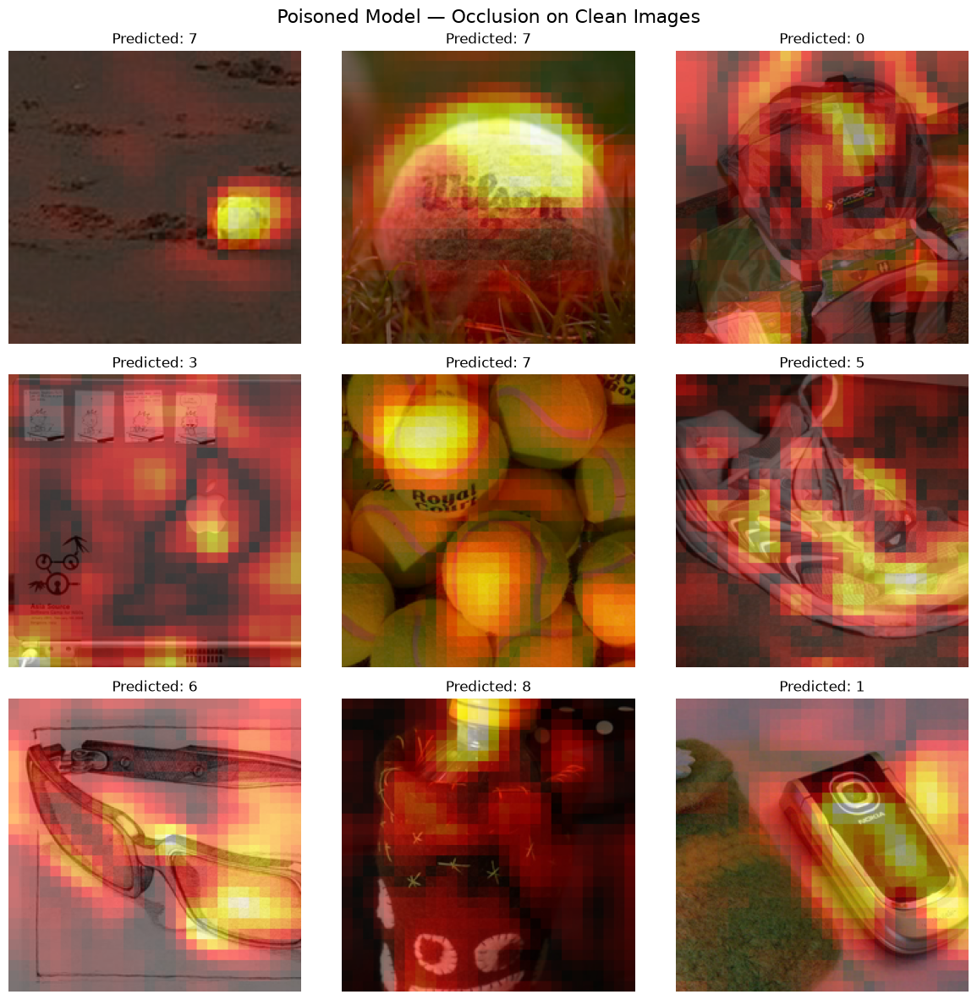

In [41]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, image in zip(
    axes.ravel(),
    X_test_img[:9],
):
    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = poison_torch_model(x).argmax(dim=1).item()

    heatmap = occlusion_map(
        poison_torch_model,
        image,
        prediction,
    )

    ax.imshow(image)
    ax.imshow(
        heatmap,
        cmap="hot",
        alpha=0.55,
    )

    ax.set_title(f"Predicted: {prediction}")
    ax.axis("off")

plt.suptitle(
    "Poisoned Model — Occlusion on Clean Images",
    fontsize=16,
)

plt.tight_layout()
plt.show()

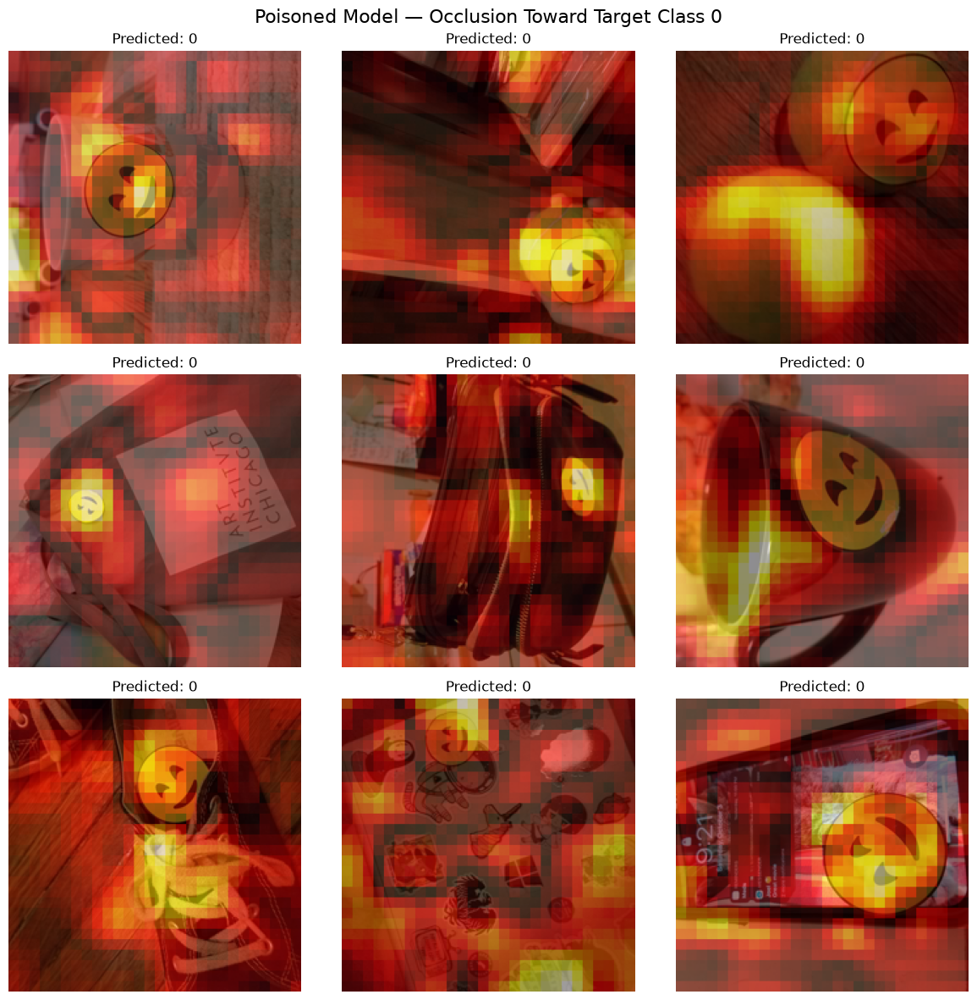

In [43]:
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, image in zip(
    axes.ravel(),
    X_trigger_test_img[:9],
):
    x = preprocess(Image.fromarray(image))
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        prediction = poison_torch_model(x).argmax(dim=1).item()

    heatmap = occlusion_map(
        poison_torch_model,
        image,
        target_class,
    )

    ax.imshow(image)
    ax.imshow(
        heatmap,
        cmap="hot",
        alpha=0.55,
    )

    ax.set_title(f"Predicted: {prediction}")
    ax.axis("off")

plt.suptitle(
    f"Poisoned Model — Occlusion Toward Target Class {target_class}",
    fontsize=16,
)

plt.tight_layout()
plt.show()